In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import pickle
import time

sys.path.append("..")
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras
import numpy as np
import matplotlib.pyplot as plt

import ydf

INFO:bayesflow:Using backend 'jax'


In [3]:
rng = np.random.default_rng(seed=1234)

In [4]:
import scipy
from scipy.integrate import odeint

def prior():
    x = rng.normal(size=4)
    theta = 1/(1+np.exp(-x)) * 3.9 + 0.1 # logit normal distribution scaled to range from 0.1 and 4
    return dict(
        alpha=theta[0],
        beta=theta[1],
        gamma=theta[2],
        delta=theta[3],
    )

def lotka_volterra_equations(state, t, alpha, beta, gamma, delta):
    x, y = state
    dxdt = alpha * x - beta * x * y
    dydt = - gamma * y + delta * x * y
    return [dxdt, dydt]

def ecology_model(alpha, beta, gamma, delta, t_span=[0, 5], t_steps=100, initial_state=[1, 1]):
    t = np.linspace(t_span[0], t_span[1], t_steps)
    state = odeint(lotka_volterra_equations, initial_state, t, args=(alpha, beta, gamma, delta))
    x, y = state.T  # Transpose to get x and y arrays
    
    return dict(
        x=x,  # Prey time series
        y=y,  # Predator time series
        t=t,  # time
    )

def observation_model(x, y, t, observation_subsampling=10, observation_probability=1, observation_noise=0.1):
    t_steps = x.shape[0]
    
    # observation noise
    observed_x = rng.normal(loc=x, scale=observation_noise)
    observed_y = rng.normal(loc=y, scale=observation_noise)
    observed_t = np.copy(t)

    # if observation_probability < 1, the population count is missing for some time steps
    random_indices = rng.choice(np.arange(0, t_steps, observation_subsampling), int(observation_probability * t_steps // observation_subsampling), replace=False)
    random_indices = np.sort(random_indices)  # rng.choice scrambles the order of observation indices
    
    return dict(
        observed_x=observed_x[random_indices],  # Prey time series
        observed_y=observed_y[random_indices],  # Predator time series
        observed_t=observed_t[random_indices],
    )

simulator = bf.make_simulator([prior, ecology_model, observation_model])

def period(observed_x, t_span=[0, 5], t_steps=500):
    """
    Computes the dominant period of observed_x from a periodogram.
    """
    f, Pxx = scipy.signal.periodogram(observed_x, t_steps/(t_span[1]-t_span[0]))
    freq_dominant = f[np.argmax(Pxx)]
    T = 1 / freq_dominant
    return T


def autocorr(trajectory, lags):
    """
    Computes the autocorrelation for each specified lag in a trajectory.
    
    Parameters
    ----------
    trajectory : np.ndarray
        The time series data, assumed to be a 1D array.
    lags : np.ndarray or list
        The lags at which to compute the autocorrelation.
    
    Returns
    -------
    auto_correlation : np.ndarray
        Autocorrelation values at each specified lag.
    """
    # Calculate the mean and variance of the trajectory for normalization
    mean = np.mean(trajectory)
    var = np.var(trajectory)
    
    # Initialize an array to hold the autocorrelation values
    auto_correlation = np.zeros(len(lags))
    
    # Compute autocorrelation for each lag
    for i, lag in enumerate(lags):
        if lag == 0:
            # Autocorrelation at lag 0 is always 1
            auto_correlation[i] = 1
        elif lag >= len(trajectory):
            # If the lag is equal to or greater than the length of the trajectory, autocorrelation is undefined (set to 0)
            auto_correlation[i] = 0
        else:
            # Compute covariance and then autocorrelation
            cov = np.mean((trajectory[:-lag] - mean) * (trajectory[lag:] - mean))
            auto_correlation[i] = cov / var

    if np.any(np.isnan(auto_correlation)):
        print(auto_correlation)
            
    return auto_correlation

def crosscorr(x, y):
    """
    Computes the cross-correlation (Pearson correlation coefficient) between two trajectories at zero lag.

    Parameters
    ----------
    x : np.ndarray
        The first time series data, assumed to be a 1D array of length n.
    y : np.ndarray
        The second time series data, assumed to be a 1D array of length n.

    Returns
    -------
    float
        The cross-correlation coefficient.
    """
    # Compute the mean and standard deviation of both time series
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    std_x = np.std(x)
    std_y = np.std(y)

    # Compute the covariance and the correlation coefficient
    covariance = np.mean((x - mean_x) * (y - mean_y))
    correlation = covariance / (std_x * std_y)

    return correlation

def expert_stats(observed_x, observed_y, lags=[2,5]):
    """Computes fixed size statistics for an observed population trajectory

    Parameters
    ----------
    observed_x : np.ndarray with shape (num_observations, )
    observed_y : np.ndarray with shape (num_observations, )

    Returns
    -------
    dictionary with the following keys and values
    means      : np.ndarray with shape (2,)
    log_vars   : np.ndarray with shape (2,)
    auto_corrs : np.ndarray with shape (2*num_lags,)
        auto-correlation of each timeseries at lags 0.2 and 0.4 time units
    cross_corr : np.ndarray with shape (1,)
        the cross-correlation between the two time series
    period     : np.ndarray with shape (1,)
    """
    means = np.array([observed_x.mean(), observed_y.mean()])
    log_vars = np.log(np.array([observed_x.var(), observed_y.var()]))
    auto_corrs = np.array([
        autocorr(observed_x,lags),
        autocorr(observed_y,lags),
    ]).flatten()
    cross_corr = crosscorr(observed_x, observed_y)
    T = period(observed_x)
    
    return dict(
        means=means,
        log_vars=log_vars,
        auto_corrs=auto_corrs,
        cross_corr=cross_corr,
        period=T,
    )

simulator = bf.make_simulator([prior, ecology_model, observation_model, expert_stats])

adapter = (
    bf.adapters.Adapter()

    # convert from numpy's default float64 to deep learning friendly float32
    .convert_dtype("float64", "float32")

    # drop unobserved full trajectories and raw observations
    .drop(["x", "y", "t", "observed_x", "observed_y", "observed_t"])
    
    # standardize hand-crafted statistics to zero mean and unit variance 
    .standardize()#include=["means", "log_vars", "auto_corrs", "cross_corr", "period"])
    
    # rename the variables to match the required approximator inputs
    .concatenate(["alpha", "beta", "gamma", "delta"], into="inference_variables")
    .concatenate(["means", "log_vars", "auto_corrs", "cross_corr", "period"], into="inference_conditions")

)

In [5]:
num_training_batches = 512 // 8
num_validation_sets = 300
batch_size = 64
epochs = 15
num_training_batches * batch_size

4096

In [6]:
training_data = simulator.sample(num_training_batches * batch_size)
validation_data = simulator.sample(num_validation_sets)

point_gradient_boosting
 Fitting finished after 6.68 seconds.
 Estimating finished after 0.0374 seconds.


INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


point_mlp
 Fitting finished after 20.97 seconds.
 Estimating finished after 0.0043 seconds.


INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


cf
 Fitting finished after 46.36 seconds.
 Estimating finished after 3.1801 seconds.


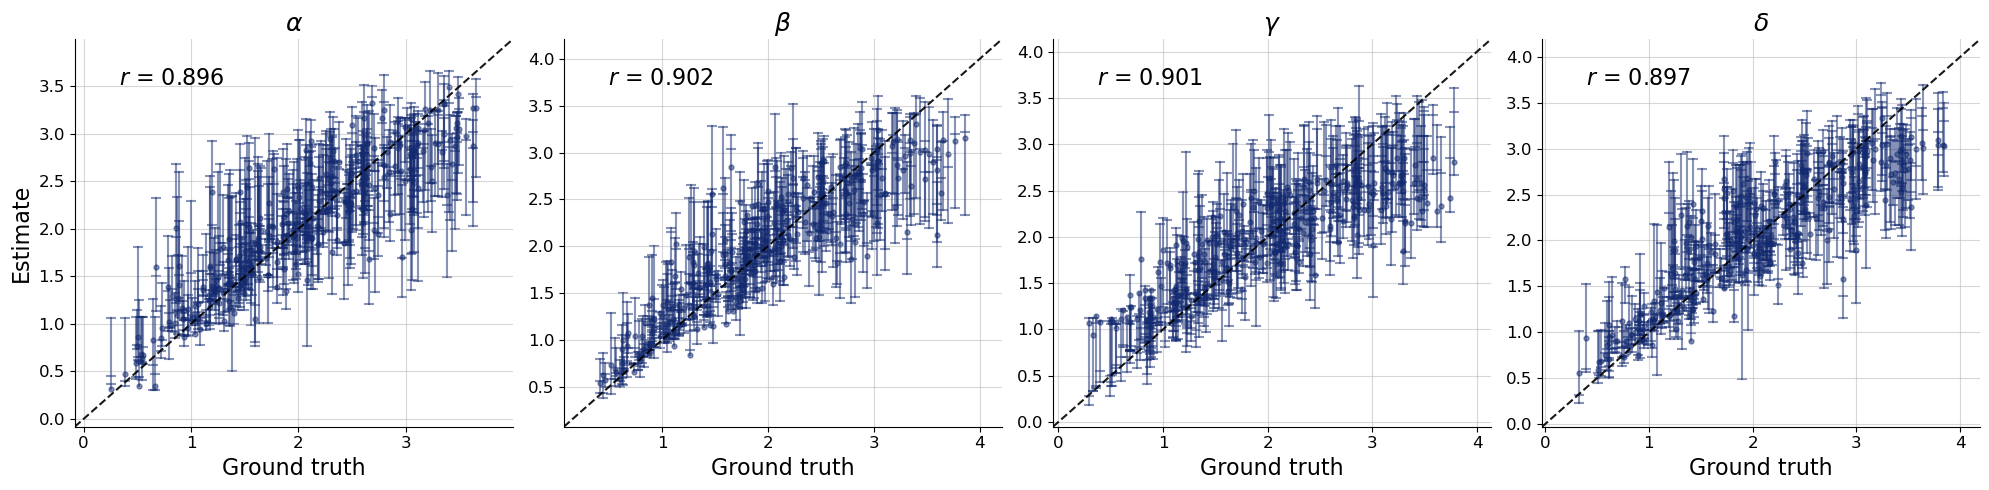

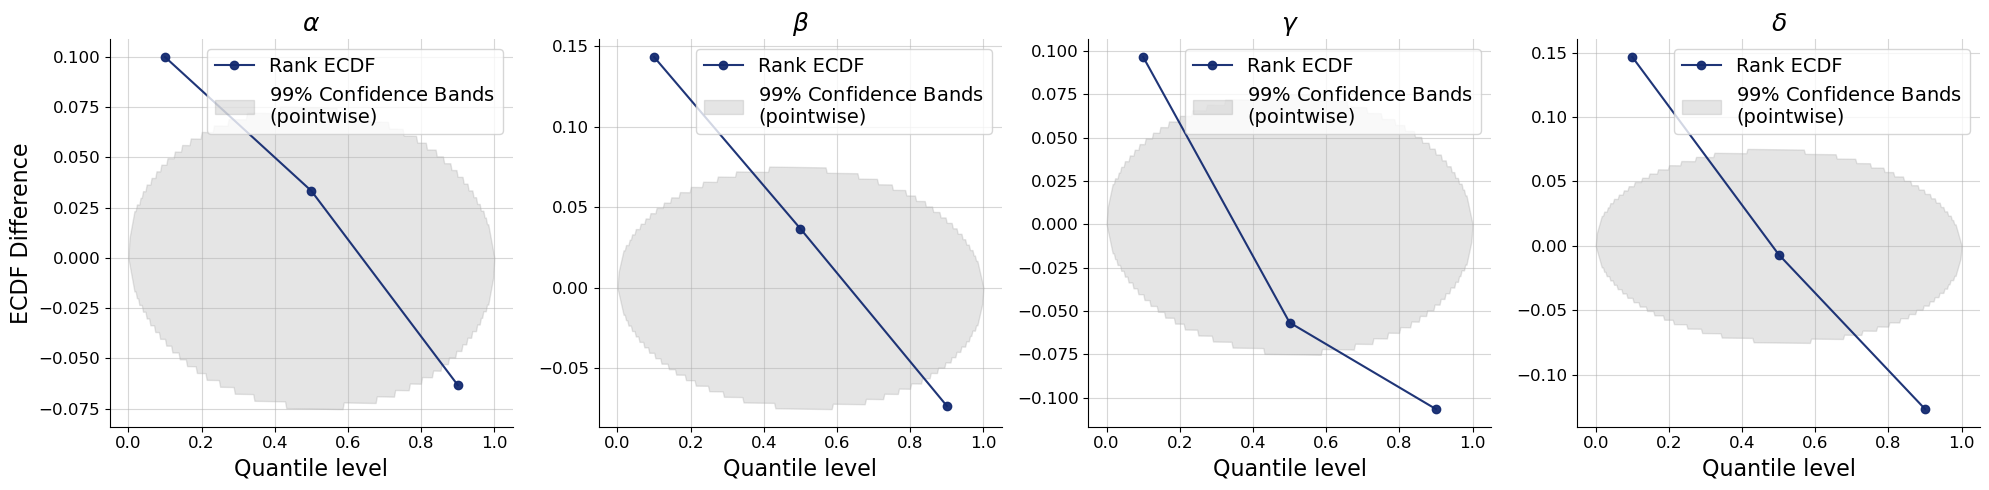

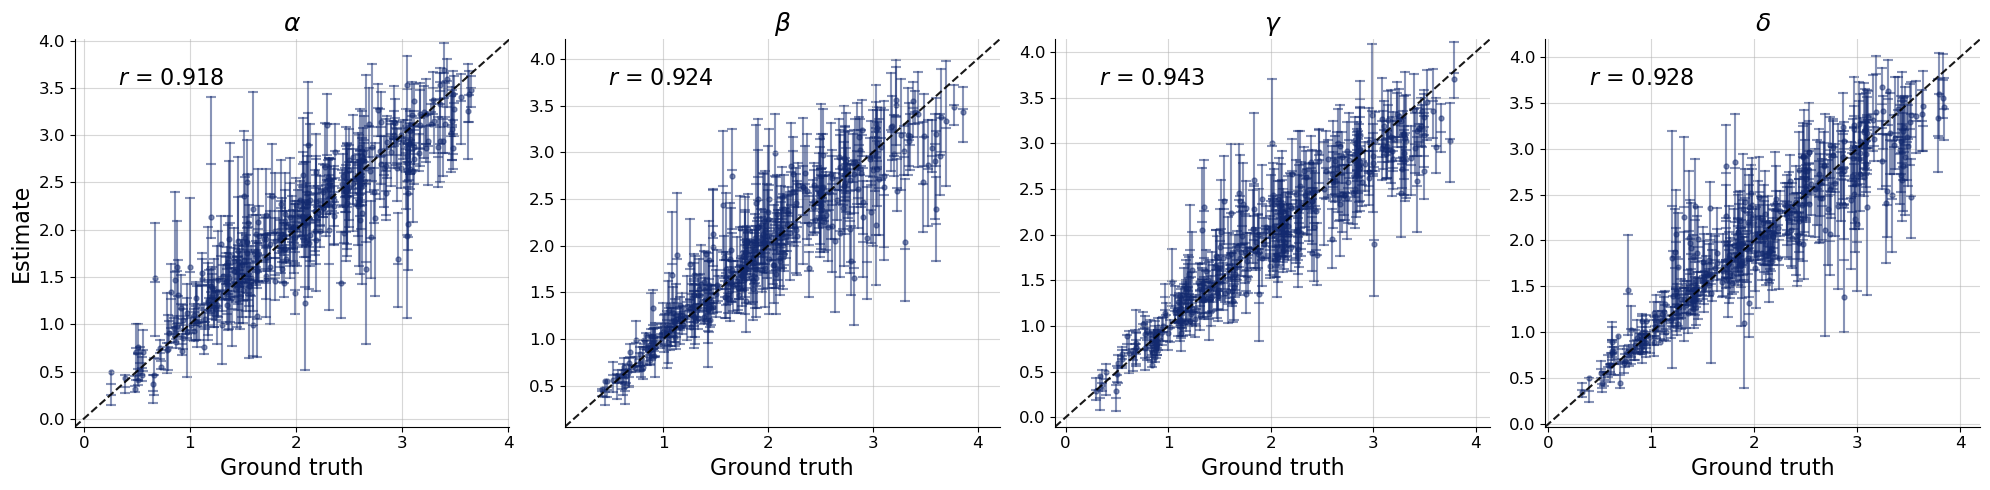

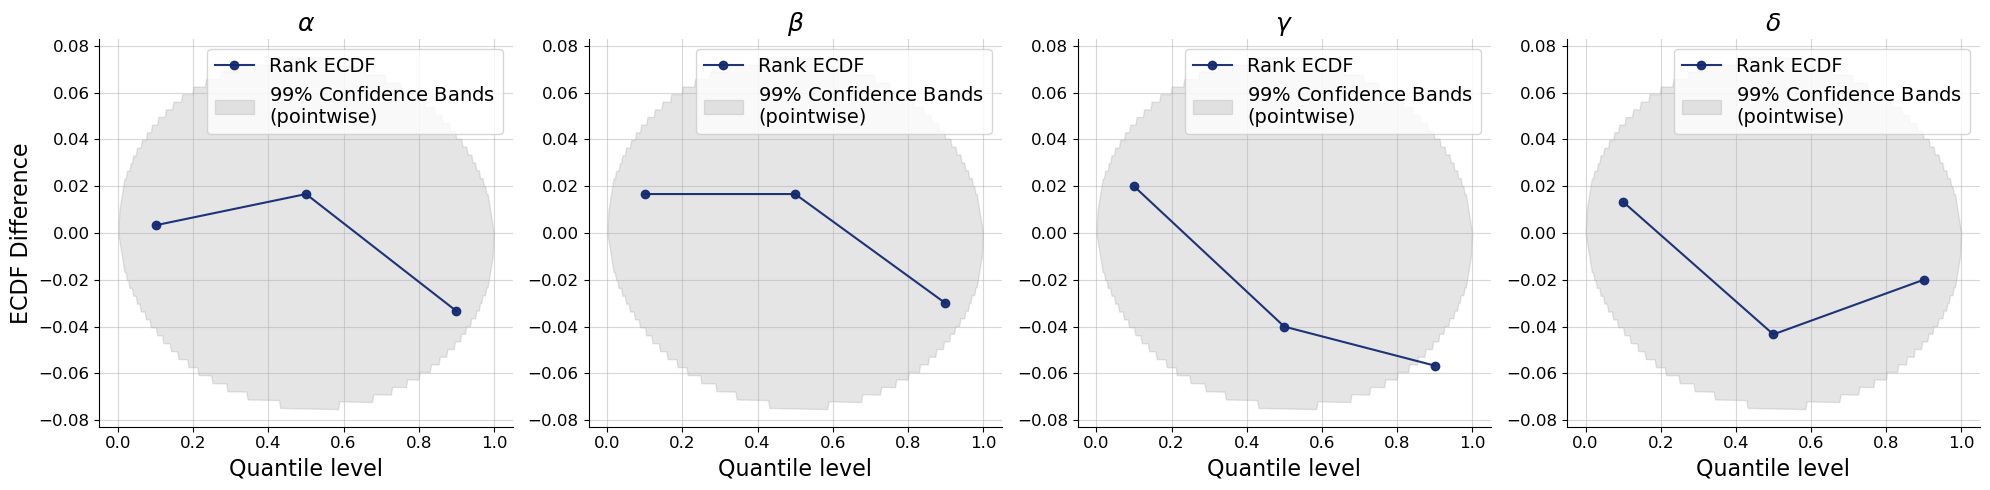

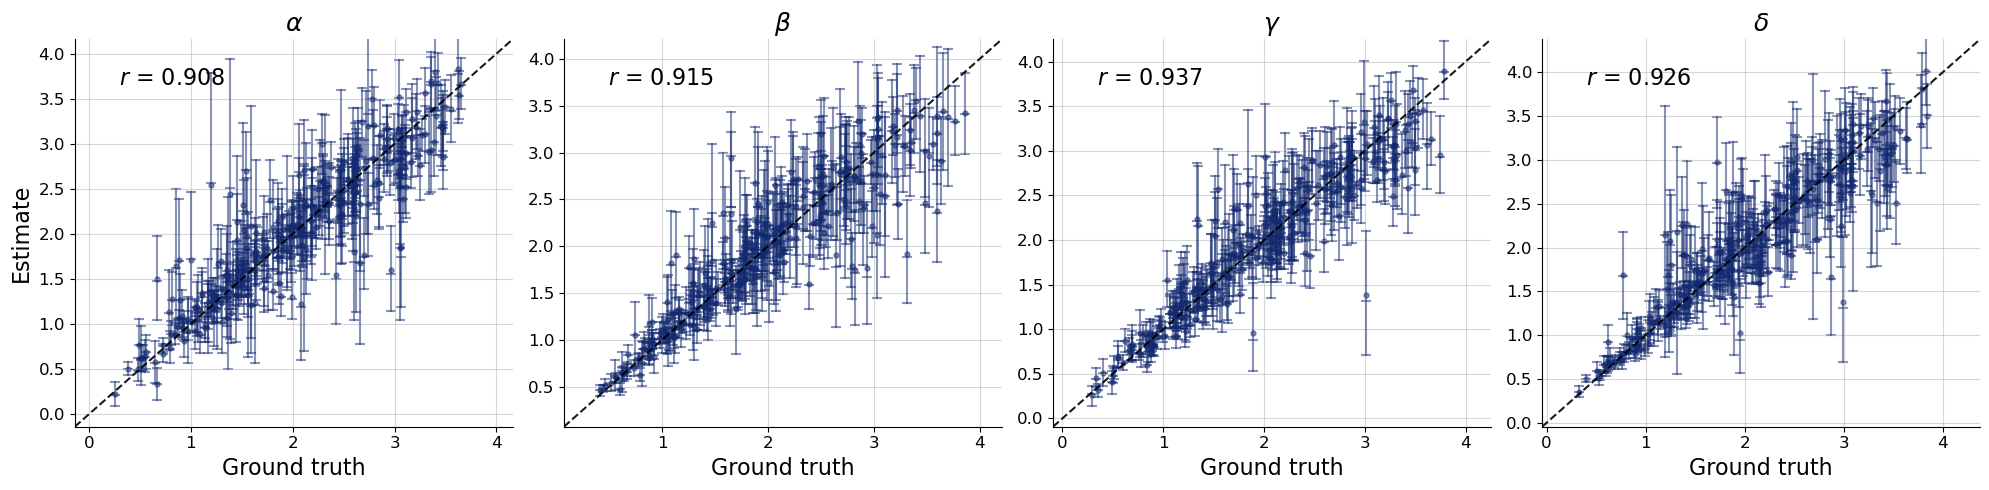

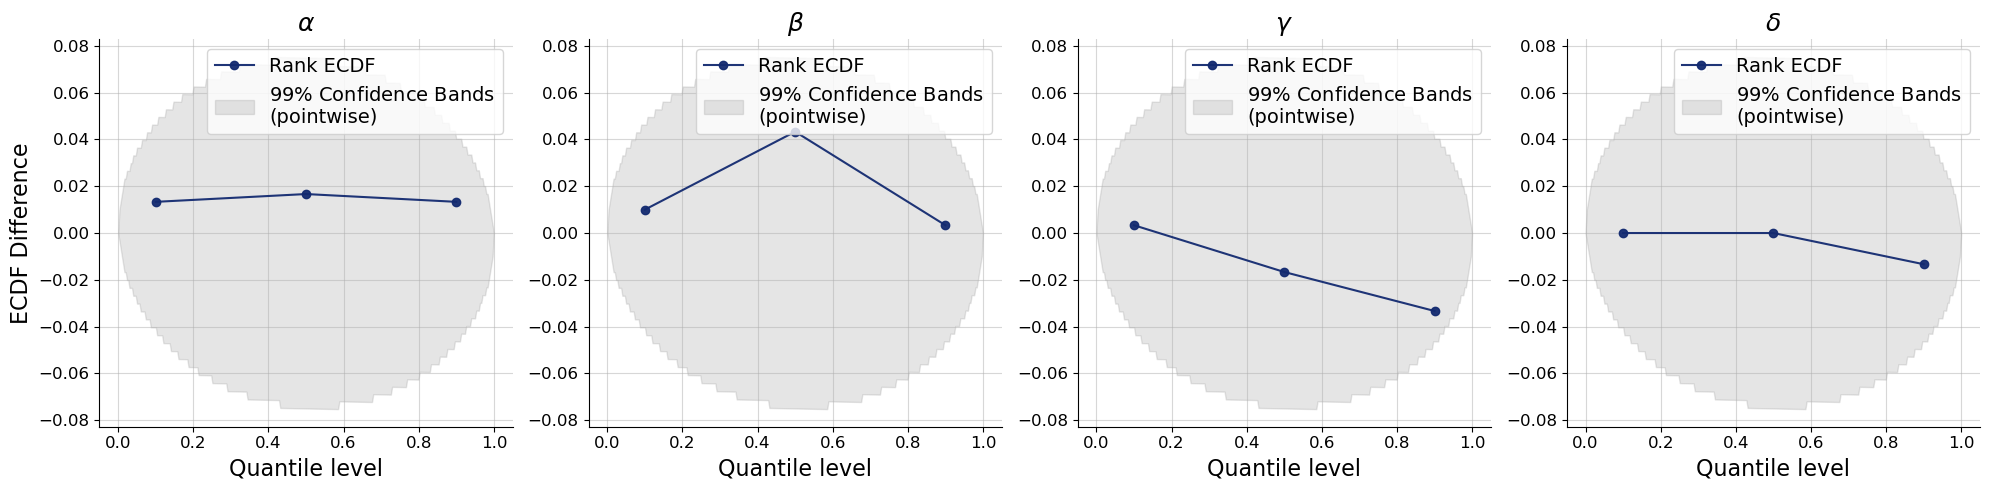

In [13]:
quantile_levels = [0.1, 0.5, 0.9]

gbworkflow = bf.wrappers.GradientBoostingWorkflow(
    simulator=simulator,
    adapter=adapter,
    scores=dict(mean=bf.scores.MeanScore(), quantiles=bf.scores.QuantileScore(quantile_levels)),
)

point_inference_network = bf.networks.PointInferenceNetwork(
    scores=dict(
        mean=bf.scores.MeanScore(),
        quantiles=bf.scores.QuantileScore(quantile_levels),
    ),
)

point_mlp_workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=point_inference_network,
)

cf_inference_network = bf.networks.CouplingFlow()
cf_workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=cf_inference_network,
)

workflows = dict(point_gradient_boosting=gbworkflow, point_mlp=point_mlp_workflow, cf=cf_workflow)

for key, workflow in workflows.items():
    print(key)

    t1 = time.time()
    history = workflow.fit_offline(data=training_data, validation_data=validation_data, verbose=0)
    t2 = time.time()
    print(f" Fitting finished after {t2-t1:.2f} seconds.")

    t3 = time.time()
    estimates = workflow.estimate(conditions=validation_data)
    t4 = time.time()
    print(f" Estimating finished after {t4-t3:.4f} seconds.")
    
    marker_mapping = dict(mean=".", quantiles="_")
    par_names = [r"$\alpha$", r"$\beta$", r"$\gamma$", r"$\delta$"]
    f = bf.diagnostics.plots.recovery_from_estimates(
        estimates=estimates,
        targets=validation_data,
        marker_mapping=marker_mapping,
        variable_names=par_names,
        s=50,  # size of markers as in matplotlib.scatter
    )

    f = bf.diagnostics.plots.calibration_ecdf_from_quantiles(
        estimates=estimates,
        targets=validation_data,
        marker_mapping=marker_mapping,
        variable_names=par_names,
        quantile_levels=quantile_levels,
        difference=True,
        s=50,  # size of markers as in matplotlib.scatter
    )